[目录](./00-A目录.ipynb)

# 概率、高斯和贝叶斯定理

In [ ]:
%matplotlib inline

In [ ]:
#format the book
import book_format
book_format.set_style()

## 简介

上一章讨论了离散贝叶斯滤波器的一些缺点。对于许多跟踪和过滤问题，我们希望有一支持个*单模态（unimodal）*和*连续（continuous）*的滤波器。也就是说，我们希望使用浮点数学（continuous）对系统建模，并且只给出一个确认的结果（unimodal）。例如，我们说一架飞机在 (12.34，-95.54，2389.5)，这里分别表示纬度、经度和高度。我们不希望滤波器告诉我们“它可能在 (1.65，-78.01，2100.45) 或 (34.36，-98.23，2543.79)”。这与我们对世界如何运作的物理直觉不符，正如我们所讨论的，计算多模态情况的代价是非常巨大的。当然，多个位置估计使得导航无法应用。

我们希望用一种单模态、连续的方式来模拟现实世界各种问题的概率，并且这种方法计算起来十分高效。高斯分布提供了这些特征。

## 均值、方差和标准差

你们中的大多数人可能都会接触过数据统计，但无论如何，请允许我介绍这些基础内容。我要求你阅读这些内容，即使你认为你已经很清楚。我这样要求是有两个原因。首先，我想确保我们使用术语的表达是相同的。第二，我努力形成对统计的直观理解，这将在后面的章节中为您提供很好的帮助。学习统计课程，并且只记住公式和计算很容易，但可能对所学内容的含意很模糊。

### 随机变量

我们每次在掷骰子时，得到的结果都在 1-6 之中。如果我们掷骰子掷一百万次，我们预计其中 1/6 会得到 1。因此，我们说结果为 1 的*概率（probability）*或*几率（odds）*是 1/6。同样地，如果我问你下一次掷骰子得到 1 的结果可能性，你会回答 1/6。

这种值和相关概率的组合称为[*随机变量（random variable）*](https://en.wikipedia.org/wiki/random_variable)。这里*随机（random）*并不意味着过程是不确定的，只是我们缺少关于结果的信息。掷骰子的结果是确定的，但我们缺乏足够的信息来计算结果。除了可能性，我们不知道会发生什么。

当我们定义术语时，值的范围称为[*样本空间（sample space）*](https://en.wikipedia.org/wiki/sample_space)。对于骰子，它的样本空间为 {1, 2, 3, 4, 5, 6}。对于硬币来说，样本空间是 {正面，反面}。*空间（space）*是一个数学术语，意思是一个集合。骰子的样本空间是 1 到 6 范围内自然数的子集。

另一个随机变量的例子是大学学生的身高。这里的样本空间是一个实数范围，介于生物学定义的两个极限值之间。

抛硬币和掷骰子等随机变量是*离散随机变量（discrete random variables）*。这意味着它们的样本空间由有限个值或可数的无限个值（如自然数）组成。人类的身高则是*连续随机变量（continuous random variables）*，因为它们可以在两个极限值之间取任何实数值。

不要将随机变量的*测量值（measurement）*与实际值混淆。如果我们测量一个人的身高的精度只能到 0.1 米，我们只能测量得到 0.1 米、0.2 米、0.3 米、2.7 米的数值，从而产生 27 个离散的值。尽管如此，一个人身高的实际值可能是这两个范围内的任意值，所以身高是一个连续的随机变量。

在统计学中，大写字母用于表示随机变量，通常用字母表的后半部分的字母。所以，我们可以说 $X$ 是代表掷骰子的随机变量，或者 $Y$ 是诗歌班新生的身高。后面的章节会使用线性代数来解决这些问题，因此我们将遵循向量使用小写，矩阵使用大写的惯例。所以会有一些冲突，你必须从上下文中确定使用的是哪一个意思。我总是用粗体符号来表示向量和矩阵，这有助于区分两者。

## 概率分布

[*概率分布*](https://en.wikipedia.org/wiki/probability_distribution)给出了随机变量在样本空间中获取某一个值的概率。例如，对于一个公平的六面骰子，我们可以说：

|Value|Probability|
|-----|-----------|
|1|1/6|
|2|1/6|
|3|1/6|
|4|1/6|
|5|1/6|
|6|1/6|

我们用小写的 p:$p(x)$ 表示这个分布。使用一般函数表示法，骰子掷到 4 的概率为：

$$P(X{=}4) = p(4) = \frac{1}{6}$$

这表明，骰子着陆时 4 朝上的概率是 $\frac{1}{6}$。$P(X{=}x_k)$ 是“随机变量 $X$ 中 $x_k$ 的概率”的符号表示。请注意细微的符号差异。大写 $P$ 表示单个事件的概率，小写 $p$ 表示概率分布函数。如果你不注意的话，这会把你引入歧途。有些文献中使用 $Pr$ 而不是 $P$ 来区分概率分布。

另一个例子是抛硬币。它的样本空间是 {H, T}。硬币是均匀的，所以头部（H）朝上的概率是 50%，图案（T）朝上的概率是 50%。我们把这个写成

$$\begin{gathered}P(X{=}H) = 0.5\\P(X{=}T)=0.5\end{gathered}$$

样本空间不是唯一的。骰子的一个样本空间是 {1, 2, 3, 4, 5, 6}。另一个有效的样本空间是 {偶数，奇数}。另一种可能是 {所有角落的点，所有不在角落的点}。只要样本空间包含所有可能的情况，并且任何单个事件仅由样本空间中的一个元素描述，那么样本空间就是有效的。{偶数，1，3，4，5} 就不是骰子的有效样本空间，因为结果若是 4，则同时与样本空间中的“偶数”和“4”匹配。

*离散随机值*的所有值的概率被称为*离散概率分布*，而*连续随机值*的所有值的概率被称为*连续概率分布*。

要成为概率分布，每个值的概率 $x_i$ 必须是 $x_i \ge 0$，因为任何概率都不能小于零。其次，所有值的概率之和必须等于 1。这对于掷硬币来说应该是显而易见的：如果获得头部的几率是 70%，那么获得尾部的几率必须是 30%。我们将此要求公式化，对于离散的分布，需满足：

$$\sum\limits_u P(X{=}u)= 1$$

对于连续的分布需满足：

$$\int\limits_u P(X{=}u) \,du= 1$$

在前一章中，我们使用概率分布来估计狗在走廊中的位置。例如：

sum =  1.0


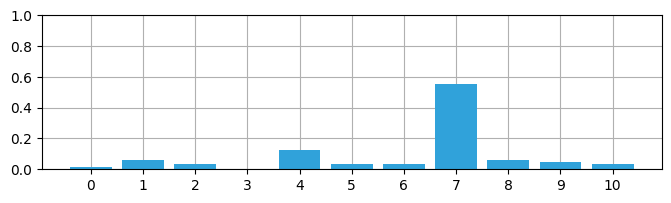

In [ ]:
import numpy as np
import kf_book.book_plots as book_plots

belief = np.array([1, 4, 2, 0, 8, 2, 2, 35, 4, 3, 2])
belief = belief / np.sum(belief)
with book_plots.figsize(y=2):
    book_plots.bar_plot(belief)
print('sum = ', np.sum(belief))

每个位置的概率在 0 到 1 之间，并且所有位置的概率和等于 1，所以这是一个概率分布。而每个概率都是离散的值，所以我们可以更精确地称之为离散概率分布。在实践中，除非我们有特殊情况需要来区分它们，通常会省略离散或连续。

### 随机变量的均值，中位数，众数

对于给定一组数据，我们通常希望知道这组数据的具有代表性的值或平均值。有很多方法可以解决这个问题，这个概念被称为[*中央趋势的测量方法（measure of central tendency）*](https://en.wikipedia.org/wiki/central_trends)。例如，我们可能想知道一个班上学生的*平均*身高。我们都知道如何找到一组数据的平均值，但是让我详细介绍一下这一点，这样我可以引入更正式的符号和术语。平均（average）的同义词是*平均（mean）*。我们通过求和并除以值的个数来计算平均值。如果学生的身高以米为单位

$$X = \{1.8, 2.0, 1.7, 1.9, 1.6\}$$

我们计算均值为

$$\mu = \frac{1.8 + 2.0 + 1.7 + 1.9 + 1.6}{5} = 1.8$$

通常上使用符号 $\mu$（mu）来表示平均值。

我们可以用方程把这个计算过程形式化。

$$ \mu = \frac{1}{n}\sum^n_{i=1} x_i$$

NumPy 提供了 `numpy.mean()` 来计算均值。

In [ ]:
x = [1.8, 2.0, 1.7, 1.9, 1.6]
np.mean(x)

1.8

为了方便起见，Numpy 数组提供了方法 `mean()`。

In [ ]:
x = np.array([1.8, 2.0, 1.7, 1.9, 1.6])
x.mean()

1.8

一组数字的*众数（mode）*是指其中最常出现的数字。如果只有一个数字最常出现，我们就说它是一个*单模态（unimodal）*集合，如果有两个或两个以上的数字出现的频率一样多则这个集合是*多模态（multimodal）*。例如，集合 {1, 2, 2, 2, 3, 4, 4, 4} 具有众数 2 和 4，这是多模的，集合 {5, 7, 7, 13} 具有众数 7，因此是单模的。在这本书中，我们不会以这种方式计算众数，但我们确实在广义的角度上使用单模和多模的概念。例如，在**离散贝叶斯**一章中，我们讨论了我们对狗的位置的确定性是*多模态分布（multimodal distribution）*，因为我们为不同的位置分配了不同的概率。

最后，一组数字的*中位数（median）*是集合的中点，这样一半的值低于中位数，一半的值高于中位数。这里，高于和低于与集合的排列顺序有关。如果集合中元素的个数是偶数，则中位数是两个中间数的平均值。

Numpy 提供了 `numpy.median()` 来计算中位数。如你所见，1.8、2.0、1.7、1.9、1.6 的中位数为 1.8，因为 1.8 是排序后该集合的第三个元素。在这例子中，中位数等于平均值，但通常情况下并不会这样。

In [ ]:
np.median(x)

1.8

## 随机变量的期望值

一个随机变量的[*期望值（expected value）*](https://en.wikipedia.org/wiki/expected_value)是我们取无限多样本下的平均值。假设我们有 $X=[1,3,5]$ 并且每个值出现的可能性都相同。我们*期望 (expect）* $X$ 的平均值是多少？

当然，这是 1、3 和 5 的平均值，也就是 3。这是有依据的；我们希望 1、3 和 5 的数目相等，所以 $(1+3+5)/3=3$ 显然是无限系列样本的平均值。换句话说，这里的期望值就是样本空间的*平均值*。

现在假设每个值都发生的概率都不同。假设 1 有 80% 的几率发生，3 有 15% 的几率发生，5 只有 5% 的几率发生。在这种情况下，我们通过将 $x$ 的每个值乘以它发生的概率百分比，并求和结果来计算预期值。对于这种情况，我们计算得出

$$\mathbb E[X] = (1)(0.8) + (3)(0.15) + (5)(0.05) = 1.5$$

这里我使用了符号 $\mathbb E[X]$ 来表示 $x$ 的期望值。有些文献中会使用 $E(x)$。$x$ 期望值是 1.5 是可以理解的，因为 $x$ 相较于 3 或 5 更有可能是 1，3 也比 5 更有可能。

我们来形式化表述下，令 $x_i$ 表示 $X$ 中第 $i$ 个元素的值，$p_i$ 表示它发生的概率。于是我们可以得到公式：

$$\mathbb E[X] = \sum_{i=1}^n p_ix_i$$

如果每个值的概率都相等，则期望值与平均值相同：

$$\mathbb E[X] = \sum_{i=1}^n p_ix_i = \frac{1}{n}\sum_{i=1}^n x_i = \mu_x$$

如果 $x$ 是连续值，我们用积分来代替求和，如下：

$$\mathbb E[X] = \int_{a}^b\, xf(x) \,dx$$

其中 $f(x)$ 是 $x$ 的概率分布函数。我们还没有介绍这个方程，但是我们将在下一章中介绍它。

我们可以用 Python 编写一些代码来仿真。在这里，我取了 1000000 个样本，并计算了我们刚刚分析计算过的分布的期望值。

In [ ]:
total = 0
N = 1000000
for r in np.random.rand(N):
    if r <= .80: total += 1
    elif r < .95: total += 3
    else: total += 5

total / N

1.500136

你可以看到计算的值十分接近分析得出的值。它不够精确，那是因为想要获取精确值需要有无限大小的样本。

### 练习

扔骰子的期望是多少？

### 答案

每一面出现的概率都是相等的，都是 1/6。所以：
$$\begin{aligned}
\mathbb E[X] &= 1/6\times1 + 1/6\times 2 + 1/6\times 3 + 1/6\times 4 + 1/6\times 5 + 1/6\times6 \\
&= 1/6(1+2+3+4+5+6)\\&= 3.5\end{aligned}$$

### 练习

给定一个连续分布

$$f(x) = \frac{1}{b - a}$$

计算 $a=0$ 和 $b=20$ 时的期望

### 答案
$$\begin{aligned}
\mathbb E[X] &= \int_0^{20}\, x\frac{1}{20} \,dx \\
&= \bigg[\frac{x^2}{40}\bigg]_0^{20} \\
&= 10 - 0 \\
&= 10
\end{aligned}$$

### 随机变量的方差

前面的计算可以告诉我们学生的平均身高，但它并没有告诉我们我们可能想知道的一切。例如，假设我们有三个班的学生，我们用 $X$、$Y$ 和 $Z$ 表示每个班学生的身高：

In [ ]:
X = [1.8, 2.0, 1.7, 1.9, 1.6]
Y = [2.2, 1.5, 2.3, 1.7, 1.3]
Z = [1.8, 1.8, 1.8, 1.8, 1.8]

使用 NumPy，我们可以看到每个班的平均高度是相同的。

In [ ]:
print(np.mean(X), np.mean(Y), np.mean(Z))

1.8 1.8 1.8


每个班学生身高的平均值都是 1.8 米，但请注意，第二个班的身高的变化量比第一个班大得多，第三个班的身高则完全没有变化。

平均值告诉我们了一些关于数据的事情，但不是所有。我们希望能够知道每个学生身高之间有多少*差异（variation）*。你可以想象这其中的一些原因。也许一个学校需要订购 5000 张课桌，而且他们想确保他们购买的课桌尺寸能够满足学生的身高范围。

统计学已经将测量值差异的概念定义为[*标准差（standard deviation）*](https://en.wikipedia.org/wiki/standard_deviation)和[*方差（variance）*](https://en.wikipedia.org/wiki/variation)。计算方差的公式是

$$\mathit{VAR}(X) = \mathbb  E[(X - \mu)^2]$$

暂时忽略这个平方，您可以看到方差是样本空间 $X$ 与平均值 $\mu:$ $(X-\mu)$ 的偏差的*期望*。稍后我将解释平方项的用途。期望值的公式是 $\mathbb E[X] = \sum\limits_{i=1}^n p_ix_i$ 这样我们就可以将其代入上面的公式中

$$\mathit{VAR}(X) = \frac{1}{n}\sum_{i=1}^n (x_i - \mu)^2$$

让我们计算这三个班身高的方差，看看我们得到了什么值，并熟悉这个概念。

$X$ 的均值是 1.8， ($\mu_x = 1.8$) ，所以

$$ 
\begin{aligned}
\mathit{VAR}(X) &=\frac{(1.8-1.8)^2 + (2-1.8)^2 + (1.7-1.8)^2 + (1.9-1.8)^2 + (1.6-1.8)^2} {5} \\
&= \frac{0 + 0.04 + 0.01 + 0.01 + 0.04}{5} \\
\mathit{VAR}(X)&= 0.02 \, m^2
\end{aligned}$$

NumPy 提供了函数 `var()` 来计算方差：

In [ ]:
print(f"{np.var(X):.2f} meters squared")

0.02 meters squared


上面的结果可能有点难以解释，为什么高度以米为单位，但方差却是平方米。因此，我们需要一个更通用的度量，即*标准差（standard deviation）*，它被定义为方差的平方根：

$$\sigma = \sqrt{\mathit{VAR}(X)}=\sqrt{\frac{1}{n}\sum_{i=1}^n(x_i - \mu)^2}$$

通常使用 $\sigma$ 表示*标准偏差*，用 $\sigma^2$ 表示*方差*。在本书的大部分内容中，我将使用 $\sigma^2$ 而不是 $\mathit{VAR}(X)$ 来表示方差，但是他们的含义是一样的。

我们计算第一个班的标准差为

$$ 
\begin{aligned}
\sigma_x &=\sqrt{\frac{(1.8-1.8)^2 + (2-1.8)^2 + (1.7-1.8)^2 + (1.9-1.8)^2 + (1.6-1.8)^2} {5}} \\
&= \sqrt{\frac{0 + 0.04 + 0.01 + 0.01 + 0.04}{5}} \\
\sigma_x&= 0.1414
\end{aligned}$$

我们可以用 NumPy 中的 `numpy.std()` 函数来验证这个计算，它用来计算标准偏差。'std'是标准偏差的通用缩写。

In [ ]:
print(f"std {np.std(X):.4f}")
print(f"var {np.std(X)**2:.4f}")

std 0.1414
var 0.0200


当然，$0.1414^2 = 0.02$，这与我们之前对方差的计算一致。

标准偏差表示什么含义呢？它告诉了我们样本之间的高度的差异有多少。“多少”不是一个数学术语。一旦我们在下一节中介绍高斯的概念，我们就能够更精确地定义它。现在我会说，对于很多事情，68％的值都在其平均值正负一个标准差内范围内。换句话说，我们可以得出结论，对于随机选择的一个班，68％的学生的身高在 1.66（1.8-0.1414）米和 1.94（1.8 + 0.1414）米之间。

我们可以画个图观察一下：

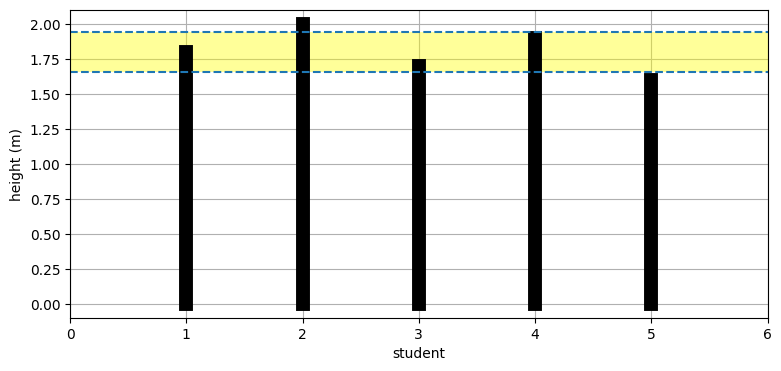

In [ ]:
from kf_book.gaussian_internal import plot_height_std
import matplotlib.pyplot as plt

plot_height_std(X)

对于只有 5 名学生的样本，我们显然无法在一个标准差内得到 68％ 的值。但我们确实可以发现 5 个学生中有 3 个在 $\pm1\sigma$ 范围内或 60％ 的样本是在的，对于 5 个样本，已经很接近 68％ 了。让我们来看看有 100 名学生的课程结果。

>我们将一个标准差写为 $1\sigma$，读做“一个标准偏差”，而不是“一个西格玛”。两个标准偏差是 $2\sigma$，依此类推。

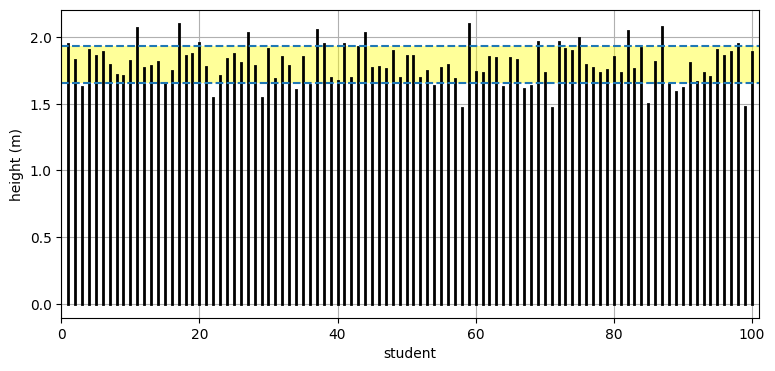

mean = 1.795
std  = 0.142


In [ ]:
from numpy.random import randn
data = 1.8 + randn(100)*.1414
mean, std = data.mean(), data.std()

plot_height_std(data, lw=2)
print(f'mean = {mean:.3f}')
print(f'std  = {std:.3f}')

粗略观察，大约 68％ 的学生的身高位于平均值 1.8 的 $\pm1\sigma$ 内，我们还可以通过代码验证这一点。

In [ ]:
np.sum((data > mean-std) & (data < mean+std)) / len(data) * 100.

67.0

我们很快就会对此进行更深入的讨论。现在让我们先计算完三个班学生身高的标准偏差

$$Y = [2.2, 1.5, 2.3, 1.7, 1.3]$$

$Y$ 的平均值 $\mu=1.8$ m, 所以

$$ 
\begin{aligned}
\sigma_y &=\sqrt{\frac{(2.2-1.8)^2 + (1.5-1.8)^2 + (2.3-1.8)^2 + (1.7-1.8)^2 + (1.3-1.8)^2} {5}} \\
&= \sqrt{0.152} = 0.39 \ m
\end{aligned}$$

我们使用 Numpy 来验证

In [ ]:
print(f'std of Y is {np.std(Y):.2f} m')

std of Y is 0.39 m


这符合我们的预期。$Y$ 的高度变化更剧烈，所以标准偏差更大。

最后，让我们计算 $Z$ 的标准差。如果值没有变化，那么我们认为标准偏差为零。

$$ 
\begin{aligned}
\sigma_z &=\sqrt{\frac{(1.8-1.8)^2 + (1.8-1.8)^2 + (1.8-1.8)^2 + (1.8-1.8)^2 + (1.8-1.8)^2} {5}} \\
&= \sqrt{\frac{0+0+0+0+0}{5}} \\
\sigma_z&= 0.0 \ m
\end{aligned}$$

In [ ]:
print(np.std(Z))

0.0


在我们继续之前，我需要指出的是，我忽略了通常男性比女性高的事实。一般而言，仅包含男性或仅包含女性的班级的高度差异将小于既有男性又有女性的班级。对于其他影响因素也是如此。营养良好的孩子比营养不良的孩子高。斯堪的纳维亚人比意大利人高。在设计实验的时候，统计人员需要综合考虑这些因素。

我们需要通过分析来决策订购学校的桌子。对于每个年龄段的学生，有两种不同的平均值 - 一类在女生的平均高度周围，一类均值在男生的平均高度周围。整个班级的平均值将介于两者之间。如果我们根据所有学生的平均值购买桌子，我们很可能最终得到的桌子既不适合学校的男生也不适合女生！

我们不会在本书中考虑这些问题。如果你需要学习处理这些问题的技巧，请查阅标准概率相关文献。

### 为什么是差值的平方

为什么我们用差值的*平方（square）*来表示方差？我们可以用大量的数学计算来证明，但让我们以一种简单的方式来看待它。下面是 $X=[3,-3,3,-3]$ 及其均值相对应的图表：

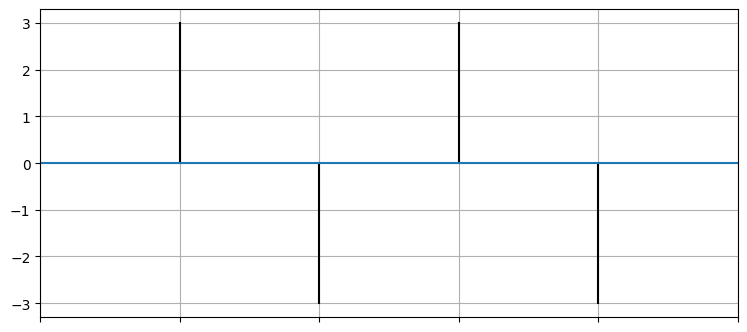

In [ ]:
X = [3, -3, 3, -3]
mean = np.average(X)
for i in range(len(X)):
    plt.plot([i ,i], [mean, X[i]], color='k')
plt.axhline(mean)
plt.xlim(-1, len(X))
plt.tick_params(axis='x', labelbottom=False)

如果我们没有计算差值的平方，那么正负号将相互抵消：

$$\frac{(3-0) + (-3-0) + (3-0) + (-3-0)}{4} = 0$$

这显然是不正确的，因为数据中的方差不止 0。

也许我们可以使用绝对值？我们可以通过计算得到结果是 $12/4 = 3$，这当然是正确的——每个值与平均值相差 3。但如果我们的样本是 $Y = [6，-2，-3,1]$，那该怎么办？在这种情况下，我们得到 $12/4 = 3$。但是 $Y$ 显然比 $X$ 更加分散，但计算的方差却一样。如果我们在公式中使用平方，我们会得到 $Y$ 的方差是 3.5，这就能反映它的变化更大。

这不是严谨的证明。事实上，该技术的发明者卡尔·弗里德里希·高斯认识到这样计算有些武断。如果存在异常值，那么对差值取平方会造成带来不成比例的权重。例如，让我们看看如果我们有以下情况会发生什么：

In [ ]:
X = [1, -1, 1, -2, -1, 2, 1, 2, -1, 1, -1, 2, 1, -2, 100]
print(f'Variance of X with outlier    = {np.var(X):6.2f}')
print(f'Variance of X without outlier = {np.var(X[:-1]):6.2f}')

Variance of X with outlier    = 621.45
Variance of X without outlier =   2.03


它是否是“正确”？你来告诉我。如果没有 100 这个异常值，我们得到 $\sigma^2 = 2.03$，这准确地反映了在没有异常值的情况下 $X$ 的变化。一个异常值掩盖了方差计算。我们是否就是想要掩盖方差计算，这样我们就知道存在异常值，或者通过有效的手段处理异常值并提供接近没有异常值的估计值？再说一次，这取决于你的问题。

我不会继续探讨下去，如果你感兴趣的话，你可以看看 James Berger 在*贝叶斯鲁棒性（Bayesian robustness）*的领域对这个问题上所做的工作，或者是由 Peter J. Huber 撰写的关于*稳健统计（robust statistics）*的书[3]。在本书中，我们将始终使用 Gauss 定义的方差和标准差。

从前面我们可以知道是，这些统计数据的*摘要*总是告诉我们有关数据的片面的部分。在这个例子中，高斯定义的方差并没有告诉我们数据中可能有一个很大的异常值。但是，它依旧是一个功能强大的工具，因为我们可以简洁地用少量数字来描述一个大型数据集。如果我们有 10 亿个数据点，我们不希望用眼睛检查图或数字列表，摘要统计为我们提供了一种有效的描述数据形状的方法。

## 高斯函数

我们现在准备介绍[高斯函数（Gaussians）](https://en.wikipedia.org/wiki/Gaussian_function)。让我先强调下本章的目的。

> 我们希望以单模态，连续的方式来表示概率，模拟现实世界如何工作，并且计算效率要高。

让我们看一下高斯分布的图形，以便了解我们所谈论的内容。

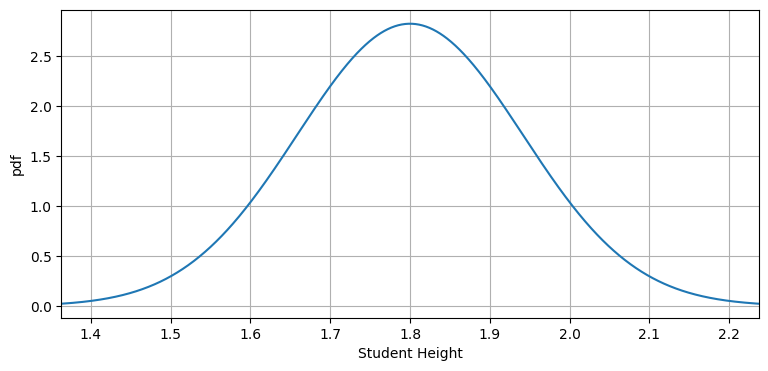

In [ ]:
from filterpy.stats import plot_gaussian_pdf
plot_gaussian_pdf(mean=1.8, variance=0.1414**2, 
                  xlabel='Student Height', ylabel='pdf');

该曲线是[*概率密度函数（probability density function）*](https://en.wikipedia.org/wiki/Probability_density_function)或简写为*pdf*。它显示了随机变量取值的相对可能性。我们可以从图表中看出，学生的身高是 1.8 m 比 1.7 m 的可能性大，而相对于 1.4 m，身高更有可能是 1.9 m。换句话说，许多学生的身高接近 1.8 m，很少有学生身高达到 1.4 m 或 2.2 m。最后，注意曲线的中心位于 1.8 m 这个平均值的地方。

> 我在 Supporting_Notebooks 文件夹中的 *Computing_and_Plotting_PDFs* 解释了如何绘制高斯函数等图形。你可以点击[这里](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/Supporting_Notebooks/Computing_and_plotting_PDFs.ipynb)在线阅读[1]。

你可以把它叫做“钟形曲线”。这种曲线无处不在，因为在现实世界的条件下，许多观测值都以这种方式分布。我不会用“钟形曲线”这样的术语来指代高斯分布，因为许多概率分布具有类似钟形的曲线形状。非数学的表述可能不那么准确，因此当您在没有定义的情况下请务必明白使用的术语。

这条曲线并不是身高所独有的——大量的自然现象都表现出这种分布，包括我们在过滤问题时使用的传感器。正如我们将要看到的，它还具有我们正在寻找的所有属性——它有唯一的峰值可以作为概率，它是连续的，并且它可以高效的计算。我们很快就会发现它还有其他我们可能没想到的优秀属性。

为了进一步说明，回想一下*离散贝叶斯*那一章中概率分布的形状：

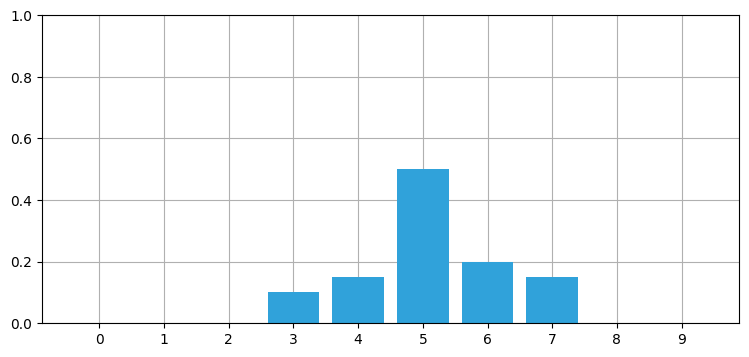

In [ ]:
import kf_book.book_plots as book_plots
belief = [0., 0., 0., 0.1, 0.15, 0.5, 0.2, .15, 0, 0]
book_plots.bar_plot(belief)

它们不是标准的高斯曲线，但它们很相似。我们可以高斯曲线来代替那一章中使用的离散概率！

## Nomenclature
## 命名

在我们继续之前有一些术语需要定义。这个图表描绘了*随机变量（probability density）*的*概率密度（random variable）*，其中任何值都在 $(-\infty..\infty)$ 之间。这意味着什么？想象一下，我们对一段高速公路上的汽车速度进行了无数次极度确的测量。然后我们可以根据以任意给定速度经过的汽车的相对数量来绘制图形。如果平均值是 120 公里/小时，它可能看起来像这样：

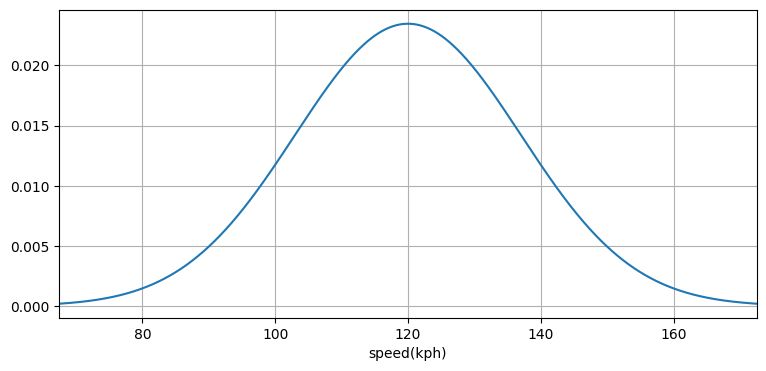

In [ ]:
plot_gaussian_pdf(mean=120, variance=17**2, xlabel='speed(kph)');

y 轴表示*概率密度（probability density）* ——在 x 轴对应速度行驶的汽车的相对数量。我将在下一节进一步解释。

高斯模型并不完美。虽然这些图表没有表现出来，但分布的*尾部（tails）*延伸到无限远。*尾部*是曲线的远端，它的值最低。当然人的高度或汽车速度不可能低于零，更不用说 $-\infty$ 或 $\infty$。毕竟“地图不是领土”，贝叶斯滤波和统计数据也是如此。上面的高斯分布模拟了所测量的汽车速度的分布，但作为模型它必然是不完美的。模型和现实之间的差异将在这些滤波器中反复出现。高斯分布在数学的许多分支中都有使用，不是因为它可以完美地模拟现实，而是因为它比任何其他相对准确的选择更容易使用。然而，在本书中，高斯分布也无法模拟现实，这迫使我们使用更多的计算太弥补。

你将听到这些分布被称为*高斯分布*或*正态分布*。*高斯*和*正态*在这种情况下都意味着相同的东西，并且可以互换使用。我将在本书中不同的地方将使用这两者中的任一名词，我希望你习惯同时看到两者。最后，如本段所述，通常缩短名称并谈论*高斯*或*正态*——这些都是*高斯分布*的典型简称。

## 高斯分布

让我们来探讨高斯分布的工作方式。高斯分布是一个*连续概率分布*，用两个参数可以完全描述，即均值（$\mu$）和方差（$\sigma^2$）。它被定义为：

$$ 
f(x, \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\big [{-\frac{(x-\mu)^2}{2\sigma^2} }\big ]
$$

$\exp[x]$ 是 $e^x$ 的一种表示方法.
 
如果你以前没见过，请不要被这个等式所唬住，你不需要记住或操纵它。该函数的计算可以要使用 `stats.py` 中的 `gaussian(x，mean，var，normed = True)`。

去掉其中的常数，你可以看到它其实是一个简单的指数函数：

$$f(x)\propto e^{-x^2}$$

它具有类似的钟形曲线形状。

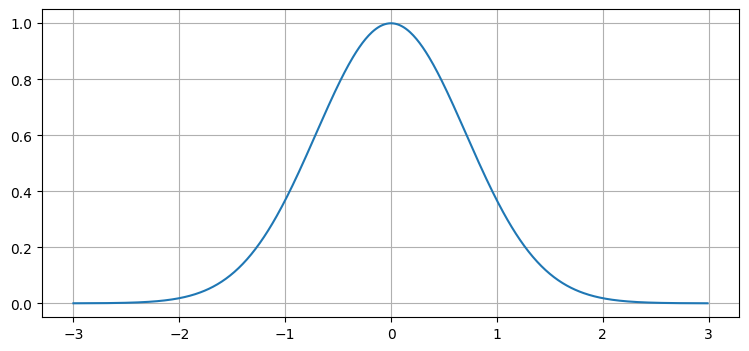

In [ ]:
x = np.arange(-3, 3, .01)
plt.plot(x, np.exp(-x**2));

让我提醒一下如何来查看函数的代码。在单元格中，键入函数名称在后面跟两个问号，然后按 CTRL + ENTER。这将打开一个显示源码的弹出窗口。取消下面单元格里的注释来尝试一下。

In [ ]:
from filterpy.stats import gaussian
#gaussian??

让我们绘制一个均值为 22 $(\mu=22)$，方差为 4 $(\sigma^2=4)$ 的高斯分布。

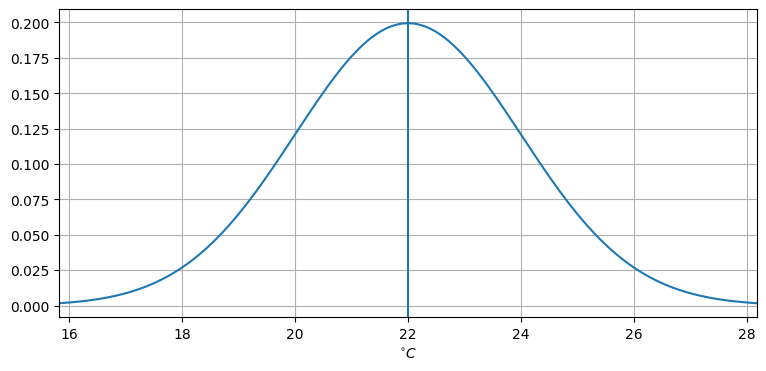

In [ ]:
plot_gaussian_pdf(22, 4, mean_line=True, xlabel='$^{\circ}C$');

这曲线表达了什么含义呢？假设我们的温度计读数为 22°C。没有一个温度计是完全准确的，因此我们认为每个读数都会略微偏离实际值。然而，一个称为[*中心极限定理（Central Limit Theorem）*](https://en.wikipedia.org/wiki/Central_limit_theorem)的定理指出，如果我们做了足够多次测量，那么测量值将是正态分布的。当我们观察这个图表时，我们可以看到温度计某次的测量值的概率与给定的实际温度 22°C 成比例。

回想一下，高斯分布是*连续*。想象一条无限长的直线——你随机选择的一个点 2 的概率显然是 0％，因为有无数种可能可供选择。正态分布也是如此; 在上图中，*测量值* 为 2°C 的概率为 0％，因为这个读数可以采用无数个值。

这条曲线是什么呢？这个我们称之为*概率密度函数*。任意区间在曲线下的面积就是该区间的概率。因此，例如，如果计算曲线下 20 到 22 之间的面积，则得到的面积将是温度读数介于这两个温度之间的概率。

还有另一种理解它的方法。什么是岩石或海绵的*密度*？它是一种衡量在给定空间内的所具有的质量的量度。岩石密集，海绵没有那么密集。所以，如果你想知道一块岩石有多重，但没有一个秤，你可以把它的体积乘以它的密度，就能得到它的质量。实际上，大多数物体的密度都不同，因此您可以将岩石体积的局部密度进行积分。

$$M = \iiint_R p(x,y,z)\, dV$$

我们用*概率密度*做同样的事情。如果你想知道温度在 20°C 到 21°C 之间的可能性，你可以将上面的曲线从 20 到 21 之间进行积分。如你所知，曲线的积分可以得到曲线下面积。由于这是概率密度的曲线，因此密度的积分就是概率。

温度恰好是 22°C 的概率是多少？直观地说是 0。在实数域，22°C 到 22.00000000000017°C 的几率是无穷小的。从数学上讲，如果我们从 22 到 22，我们会得到什么？零。

回想一下岩石，岩石上单点的重量是多少？无穷小的点必然没有重量。询问单个点的重量是没有意义的，而询问连续分布中单个值的的概率也是没有意义的。两者的答案显然都是零。

在实际中，我们的传感器没有无限的精度，因此 22°C 的读数意味着一个范围，例如 22 $ \pm $ 0.1°C，我们可以通过计算从 21.9 到 22.1 的积分来得到该范围的概率。

我们可以用频率学派 (Frequentist) 或贝叶斯 (Bayesian) 学派的术语来考虑这一点。从贝叶斯的角度，如果温度计精确的读数为 22°C，那么通过曲线描述我们的认知 —— 我们相信实际（系统）温度接近 22°C 的概率是非常高的，我们相信实际温度接近 18°C 概率非常低。我们常说，如果我们在 22°C 时对系统进行 10 亿次温度测量，那么测量的直方图就会像上面的曲线。

如何计算曲线下的概率或面积？你可以对高斯的方程做积分

$$ \int^{x_1}_{x_0}  \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}{(x-\mu)^2}/\sigma^2 } dx$$

这称为*累积概率分布（cumulative probability distribution）*，通常缩写为*cdf*。

我写了一个 `filterpy.stats.norm_cdf` 函数，它可以帮助你计算积分。例如，我们可以计算

In [ ]:
from filterpy.stats import norm_cdf
print('Cumulative probability of range 21.5 to 22.5 is {:.2f}%'.format(
      norm_cdf((21.5, 22.5), 22,4)*100))
print('Cumulative probability of range 23.5 to 24.5 is {:.2f}%'.format(
      norm_cdf((23.5, 24.5), 22,4)*100))

Cumulative probability of range 21.5 to 22.5 is 19.74%
Cumulative probability of range 23.5 to 24.5 is 12.10%


平均值（$ \mu $）看起来像是所有可能概率的平均值。由于曲线是对称的，它也是曲线的最高的地方。温度计读数为 22°C，这就是我们使用的平均值。

随机变量 $X$ 的正态分布符号是 $X \sim\ \mathcal{N}(\mu,\sigma^2)$ 其中 $\sim$ 表示*分布属于*。这意味着我可以将温度计的温度读数表示为

$$\text{temp} \sim \mathcal{N}(22,4)$$

这一点非常重要的。高斯可以让我们只用两个数字就能表示无数个可能的值！通过 $\mu=22$ 和 $\sigma^2=4$ ，我可以计算测量值在任意区间的分布。

有的文献会使用 $\mathcal N (\mu, \sigma)$ 来表示高斯分布，而不是 $\mathcal N (\mu, \sigma^2)$。这两种方式都可以，它们都是惯用的表达方法。当你看到 $\mathcal{N}(22,4)$ 这样的公式时，你需要知道它表示什么含义。在本书中，我通常使用 $\mathcal N (\mu, \sigma^2)$，就像本例中 $\sigma=2$, $\sigma^2=4$。

## 方差与置信度

由于这样的曲线表示概率密度分布，因此要求曲线下面积始终等于 1。这应该很好理解——曲线下的区域代表所有可能的结果，*这些可能发生的事件的概率和*是 1，所以密度的总和必须为 1。我们可以用一些代码来证明这一点。（如果你倾向于数学表达，那就是将高斯方程从 $-\infty$ 积分到 $\infty$）

In [ ]:
print(norm_cdf((-1e8, 1e8), mu=0, var=4))

1.0


这引出了一个重要的结论。如果方差很小，那么曲线将变窄。这是因为方差是*样本与平均值之间的差异*的度量。要使面积等于 1，曲线最高点必须很高。另一方面，如果方差很大，曲线将变宽，那么它必须变低以使面积等于 1。

让我们以图形方式看一下。我们将使用前面提到的 `filterpy.stats.gaussian`，它可以输入单个值或数组。

In [ ]:
from filterpy.stats import gaussian

print(gaussian(x=3.0, mean=2.0, var=1))
print(gaussian(x=[3.0, 2.0], mean=2.0, var=1))

0.24197072451914337
[0.378 0.622]


默认情况下，`gaussian` 会归一化输出，将输出转换回概率分布。我们可以使用参数 `normed` 来控制它。

In [ ]:
print(gaussian(x=[3.0, 2.0], mean=2.0, var=1, normed=False))

[0.242 0.399]


如果高斯的结果没有归一化，则称为*高斯函数*而不是*高斯分布*。

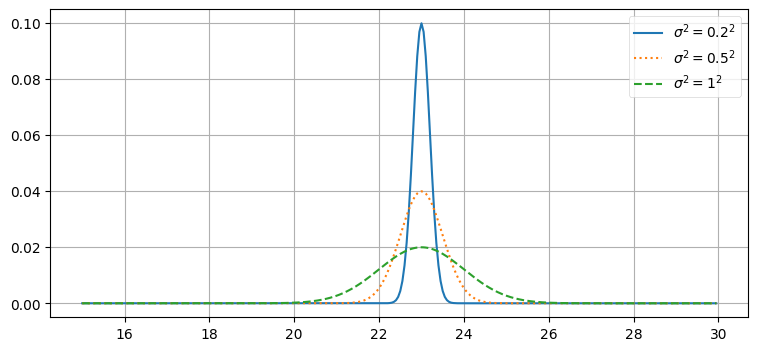

In [ ]:
xs = np.arange(15, 30, 0.05)
plt.plot(xs, gaussian(xs, 23, 0.2**2), label='$\sigma^2=0.2^2$')
plt.plot(xs, gaussian(xs, 23, .5**2), label='$\sigma^2=0.5^2$', ls=':')
plt.plot(xs, gaussian(xs, 23, 1**2), label='$\sigma^2=1^2$', ls='--')
plt.legend();

上图告诉了我们什么？$\sigma^2=0.2^2$ 的高斯分布非常窄，我们认为 $x=23$ 的可能性非常高：误差在 $\pm 0.2$。相比之下，$\sigma^2=1^2$ 的高斯分布也会认为有可能 $x=23$，但我们不能太确定。我们认为 $x=23$ 可能性很低，我们认为 $x$ 可能的值是分散的——我们认为很可能是 $x=20$ 或 $x=26$。$\sigma^2=0.2^2$ 则几乎完全排除了可能的值是 $22$ 或 $24$ 的情况，而 $\sigma^2=1^2$ 认为它们几乎与 $23$ 的可能性是一样的。

我们回忆一下前面的温度计，我们可以将这三条曲线视为三个不同温度计的读数。$\sigma^2=0.2^2$ 的曲线代表一个非常精确的温度计，$\sigma^2=1^2$ 的曲线代表一个相当不准确的温度计。请注意高斯分布为我们提供的非常强大的属性——我们可以只用两个数字——均值和方差——来代表温度计的读数和误差。

高斯分布的等价形式可以写成是 $\mathcal{N}(\mu,1/\tau)$ ，其中 $\mu$ 表示*均值*，$\tau$ 是*精确度（precision）*。$1/\tau = \sigma^2$; 它是方差的倒数。虽然我们在本书中没有使用这个公式，但它强调了方差是衡量数据精确程度的指标。方差越小精度越大——我们的测量越精确。相反，较大的方差会导致精度降低——我们的置信区间会在很大的范围内。你应该习惯于以这些等价的形式思考高斯分布。在贝叶斯中，高斯分布反映了我们对于测量值的*置信度（belief）*，它们表示测量的*精度（precision）*，它们还表示测量值的*方差*是多少。这些都是陈述相同事实的不同表述方式。

我这样讲有些提前，但在接下来的章节中，我们将使用高斯来表达我们估计跟踪对象位置的置信度或我们正在使用的传感器的准确性等信息。

## 68-95-99.7 法则
现在需要对标准差多讲一些。标准差是衡量数据偏离平均值的量度。对于高斯分布，68％的数据落在平均值的一个标准差 ($\pm1 \sigma$) 内，95％落在两个标准差 ($\pm2 \sigma$) 内，99.7％落在三个标准差 ($\pm3 \sigma$) 内。通常被称为[68-95-99.7 法则（经验法则）](https://en.wikipedia.org/wiki/68–95–99.7_rule)。如果你被告知一个班级的平均考试成绩为 71，标准差为 9.4，你可以得出结论，如果服从正态分布，那么 95％ 的学生得分在 52.2 和 89.8 之间（按 $71 \pm (2 * 9.4)$ 计算）。

最后，这些不是无意义的数字。如果高斯分布表述我们的位置是 $\mu = 22$ 米，那么标准差的单位也是米。因此如果 $\sigma = 0.2$ ，那么意味着 68％的测量范围从 21.8 米到 22.2 米。方差是标准偏差的平方，因此 $\sigma^2 =0.04$ 平方米。正如你在上一节中所看到的，编写 $\sigma^2 = 0.2^2$ 可以看起来更有意义，因为 0.2 和测量数据的单位相同。

下图描绘了标准差与正态分布之间的关系。

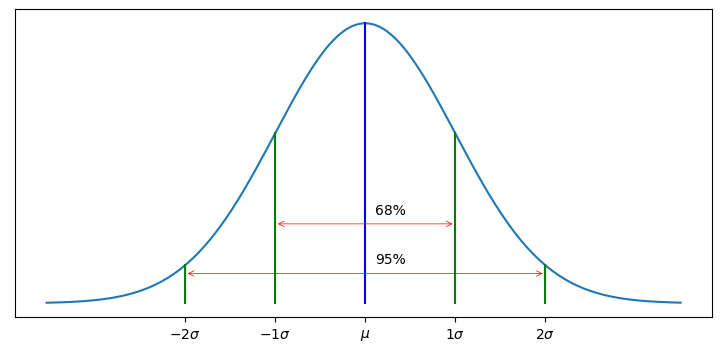

In [ ]:
from kf_book.gaussian_internal import display_stddev_plot
display_stddev_plot()

## 高斯分布交互实验

对于那些使用 Jupyter Notebook 的读者，这里提供了一个绘制高斯分布的交互式版本。可以使用滑块修改 $\mu$ 和 $\sigma^2$。调整 $\mu$ 会使图形向左或向右移动，调整 $\sigma^2$ 会使钟形曲线变得更宽或者更窄。

In [ ]:
import math
from ipywidgets import interact, FloatSlider

def plt_g(mu,variance):
    plt.figure()
    xs = np.arange(2, 8, 0.01)
    ys = gaussian(xs, mu, variance)
    plt.plot(xs, ys)
    plt.ylim(0, 0.04)

interact(plt_g, mu=FloatSlider(value=5, min=3, max=7),
         variance=FloatSlider(value = .03, min=.01, max=1.));

interactive(children=(FloatSlider(value=5.0, description='mu', max=7.0, min=3.0), FloatSlider(value=0.03, desc…

最后，如果你是在线阅读，这里有一个高斯分布的动画。首先，平均值向右移动。然后均值 以 $\mu = 5$ 为中心，方差会发生变化。

<img src='animations/04_gaussian_animate.gif'>

## 高斯分布的计算性质

离散贝叶斯滤波器通过乘以和加上任意的概率分布来工作。卡尔曼滤波器使用高斯而不是任意分布，但算法的其余部分保持不变。这意味着我们需要乘以并加上高斯分布。

高斯分布的一个显着特性是[两个独立高斯分布的随机变量的和](https://en.wikipedia.org/wiki/Sum_of_normally_distributed_random_variables)是另一个高斯分布！两个高斯分布的乘积虽然不是高斯分布，但是与高斯分布成比例。我们可以说两个高斯分布相乘的结果是高斯函数（在这个上下文中的调用的函数不能保证所有值的和为 1）。

在我们进行数学运算之前，让我们先在视觉上进行测试一下。

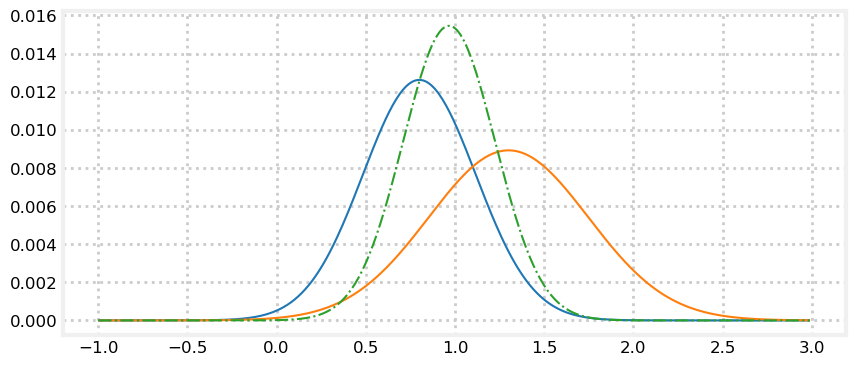

In [ ]:
x = np.arange(-1, 3, 0.01)
g1 = gaussian(x, mean=0.8, var=.1)
g2 = gaussian(x, mean=1.3, var=.2)
plt.plot(x, g1, x, g2)

g = g1 * g2  # element-wise multiplication
g = g / sum(g)  # normalize
plt.plot(x, g, ls='-.');

在这里，我实现了两个高斯分布，g1=$\mathcal N(0.8, 0.1)$ 和 g2=$\mathcal N(1.3, 0.2)$ 并绘制它们。然后我将它们相乘并将结果归一化。如您所见，结果*看起来*像是高斯分布。

高斯分布是非线性函数。通常，如果将多个非线性方程相乘，则最终会得到不同类型的函数。例如，两个正弦函数相乘的结果与 `sin（x）` 差异很大。

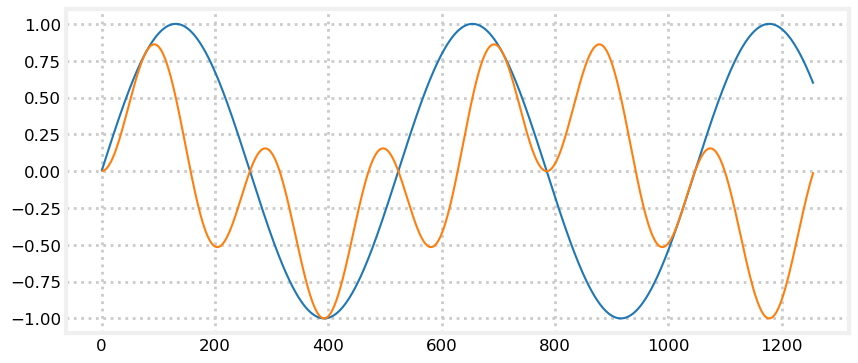

In [ ]:
x = np.arange(0, 4*np.pi, 0.01)
plt.plot(np.sin(1.2*x))
plt.plot(np.sin(1.2*x) * np.sin(2*x));

但是两个高斯分布相乘的结果却是高斯函数。这是卡尔曼滤波器在计算上可行的关键因素。换句话说，卡尔曼滤波器使用高分布斯是*因为*它们是好计算。

两个独立的高斯分布的乘积可以由下面的公式计算：

$$\begin{aligned}\mu &=\frac{\sigma_1^2\mu_2 + \sigma_2^2\mu_1}{\sigma_1^2+\sigma_2^2}\\
\sigma^2 &=\frac{\sigma_1^2\sigma_2^2}{\sigma_1^2+\sigma_2^2} 
\end{aligned}$$

两个高斯分布相加可以由下面的公式计算：

$$\begin{gathered}\mu = \mu_1 + \mu_2 \\
\sigma^2 = \sigma^2_1 + \sigma^2_2
\end{gathered}$$

在本章的最后，我会推导出这些公式式。但是，理解这些推导并不是十分重要。

## 把它们合到一起吧

现在我们准备谈论如何使用高斯分布实现滤波。在下一章中，我们将使用高斯分布实现一个过滤器。在这里，我将先解释为什么我们要使用高斯分布。

在前一章中，我们用数组表示概率分布。我们通过计算该分布的元素与另一个分布的乘积来表示每个点的测量值可能性来执行更新计算，如下所示：

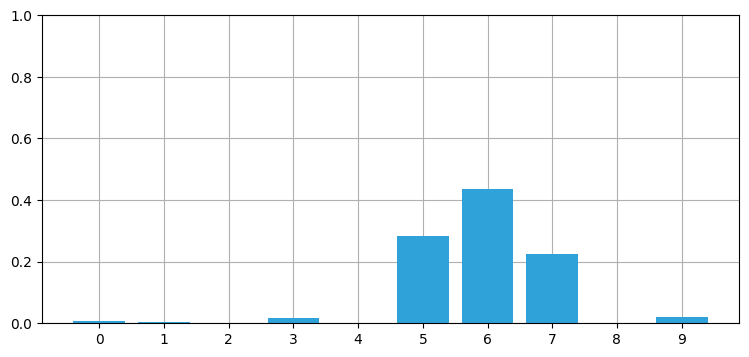

In [ ]:
def normalize(p):
    return p / sum(p)

def update(likelihood, prior):
    return normalize(likelihood * prior)

prior =      normalize(np.array([4, 2, 0, 7, 2, 12, 35, 20, 3, 2]))
likelihood = normalize(np.array([3, 4, 1, 4, 2, 38, 20, 18, 1, 16]))
posterior = update(likelihood, prior)
book_plots.bar_plot(posterior)

换句话说，我们必须计算 10 次乘法才能得到这个结果。对于现实中需要处理多维度的大矩阵的滤波器，我们需要数十亿次乘法和大量内存。

但这种分布看起来像高斯分布。如果我们使用高斯分布而不用数组会怎么样？我将计算后验概率的均值和方差，并将其与条形图进行对比。

mean: 5.88 var: 1.24


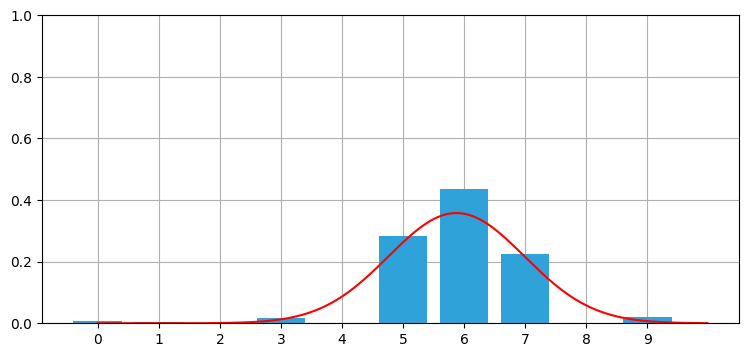

In [ ]:
xs = np.arange(0, 10, .01)

def mean_var(p):
    x = np.arange(len(p))
    mean = np.sum(p * x,dtype=float)
    var = np.sum((x - mean)**2 * p)
    return mean, var

mean, var = mean_var(posterior)
book_plots.bar_plot(posterior)
plt.plot(xs, gaussian(xs, mean, var, normed=False), c='r');
print('mean: %.2f' % mean, 'var: %.2f' % var)

结果令人吃惊。我们可以用两个数字来描述整个数字分布。也许这个例子没有说服力，因为给出的数组中只有 10 个数字。但即使真正的问题可能有数百万个数字，但仍然只需要两个数字来描述它。

接下来，回忆一下我们的滤波器实现的更新功能
```python
def update(likelihood, prior):
    return normalize(likelihood * prior)
```

如果数组包含一百万个元素，那就是一百万个乘法。但是，如果我们用高斯分布替换数组，那么我们只需要执行三个乘法和两个除法

$$\begin{aligned}\mu &=\frac{\sigma_1^2\mu_2 + \sigma_2^2\mu_1}{\sigma_1^2+\sigma_2^2}\\
\sigma^2 &=\frac{\sigma_1^2\sigma_2^2}{\sigma_1^2+\sigma_2^2} 
\end{aligned}$$

### 贝叶斯定理

在上一章中，我们通过推理每个时刻的信息来编写算法，我们将其表示为离散概率分布。在这个过程中我们学习了[*贝叶斯定理*](https://en.wikipedia.org/wiki/Bayes%27_theorem)。贝叶斯定理告诉我们如何计算给定先验信息的事件的概率。

我们根据这种概率计算方法实现了 `update()` 函数：

$$ \mathtt{posterior} = \frac{\mathtt{likelihood}\times \mathtt{prior}}{\mathtt{normalization}}$$ 

事实证明这是贝叶斯定理。我紧接着给出了数学表达，但在许多方面，它淡化了这个等式中所表达的简单概念。我们这样表示：

$$ updated\,knowledge = \big\|likelihood\,of\,new\,knowledge\times prior\, knowledge \big\|$$

其中 $\| \cdot\|$ 表示归一化。

我们通过这个简单的推理来知道一条狗在走廊上的位置。然而，正如我们将要看到的，同样的等式适用于滤波问题。我们将在随后的每一章中使用这个等式。

要回顾一下，*先验概率*是在我们测量（*似然*）之前发生事件的概率，而*后验概率*是我们在合并测量出的信息之后计算出的概率。

贝叶斯定理

$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}$$

$P(A \mid B)$ 被称为[*条件概率*](https://en.wikipedia.org/wiki/Conditional_probability)。也就是说，它表示*如果* $B$ 发生，那么 $A$ 发生的概率。例如，如果昨天下雨，那么今天下雨的可能性也更大，因为雨天通常持续一天以上。我们用 $P$（今天下雨 $\mid$ 昨天下雨）表示今天下雨的可能性。

我已经掩盖了一个重要的问题。在上面的代码中，我们不使用单个概率，而是使用一个概率数组——*概率分布*。我刚才给出的贝叶斯方程中使用的是概率，而不是概率分布。然而，它对于概率分布同样有效。我们用小写$p$表示概率分布

$$p(A \mid B) = \frac{p(B \mid A)\, p(A)}{p(B)}$$

在上述方程中，$B$ 是*依据（evidence）*，$p(A)$ 是*先验概率*，$p(B \mid A)$ 是*可能性*，$p(A \mid B)$ 是*后验概率*。通过用相应的词替换数学术语，您就能将贝叶斯定理与更新方程联系起来。让我们根据我们的问题重写更新方程。我们将使用 $x_i$ 表示第*i*个位置，使用 $z$ 表示测量值。我们想知道是 $P(x_i \mid z)$，也就是说，在给定测量值$z$的情况下，狗处于 $x_i$ 的概率。

那么，让我们把它代入方程，然后求解它。

$$p(x_i \mid z) = \frac{p(z \mid x_i) p(x_i)}{p(z)}$$

看起来不好理解，但实际上很简单。让我们弄清楚右边的每一个术语代表什么意思。第一个值是 $p(z\mid x_i)$。它表示每个位置 $x_i$ 测量值的可能性或概率。$p(x_i)$ 是*先验概率*——我们在合并测量之前的置信度。我们把它们相乘。这就是 `update()` 函数中未归一化之前的乘法：

```python
def update(likelihood, prior):
    posterior = prior * likelihood   # p(z|x) * p(x)
    return normalize(posterior)
```

最后一个要考虑的术语是分母 $p(z)$。这是在不考虑位置的情况下获得测量值 $z$ 的概率。它通常被称为*依据*。我们通过在代码中取 $x$ 或 `sum(belif)` 来计算。这就是我们计算标准化的方法！所以，`update()` 函数只不过是在计算贝叶斯定理。

在其他文献经常以积分的形式给出这些方程。毕竟，积分是一个连续函数的和。所以，你可能会看到贝叶斯定理被写成如下形式：

$$p(A \mid B) = \frac{p(B \mid A)\, p(A)}{\int p(B \mid A_j) p(A_j) \,\, \mathtt{d}A_j}\cdot$$

这个分母通常不可能用解析法求解；当它能被求解时，数学是极其困难的。最近，英国皇家统计学会（Royal Statistics Society）发布了一篇[意见文章](http://www.statslife.org.uk/opinion/2405-we-need-to-rethink-how-we-teach-statistics-from-the-ground-up)称之为“小狗的早餐”[8]。采用贝叶斯方法的滤波教科书中充满了不含解析解的积分方程。不要被这些方程吓倒，因为我们可以通过标准化我们的后验概率来处理这个积分。我们将在**粒子过滤器**一章中学习更多处理此问题的技术。在此之前，我们要认识到，在实践中通过对其求和是实现标准化的一个途经。我想说的是，当你面对一页积分时，把它们看作是求和，并把它们与本章联系起来，困难往往就会消失。问问自己“为什么我们要把这些值加起来”，“为什么我要除以这个值”。令人惊讶的是，答案往往是显而易见的，而作者经常不会提及这种解释。

你可能还没有完全明白贝叶斯定理的优点。我们要计算 $p(x_i\mid z)$。也就是说，在第 i 步，给定一个测量值，我们的可能状态是什么。这是一个非常困难的问题。贝叶斯定理是一般定理。我们可能想知道，根据癌症测试的结果，我们患癌症的可能性，或者根据不同的传感器读数，我们下雨的可能性。这样说问题似乎无法解决。

但是 Bayes 定理让我们可以用逆向计算 $P(z\mid x_i)$，这通常很容易计算：

$$p(x_i \mid Z) \propto p(Z\mid x_i)\, p(x_i)$$

也就是说，为了计算已知某个传感器读数的前提下降雨的可能性，我们只需计算下雨时传感器读数的可能性！这是一个简单得多的问题！嗯，天气预报仍然是一个难题，但是贝叶斯使它变得容易处理。

同样，正如你在离散贝叶斯章节中看到的，我们通过计算给定位置 `x` 下传感器读数的可能性，计算出西蒙在走廊任何给定位置的可能性。困难的问题变得容易。

### 全概率定理

现在我们知道了 `update()` 函数背后的数学含义；那么 `predict()` 函数呢？` predict()` 实现了[*全概率定理（total probability theorem）*](https://en.wikipedia.org/wiki/law_total_probability)。让我们回忆一下 `predict()` 计算的内容。它根据所有可能的运动事件的概率，计算出在任意给定位置的概率。让我们把它表示为一个等式。在任意位置 $i$ 在时刻 $t$ 的概率可以写为 $P(X_i^t)$。它等于前一时刻 $T-1$ 位于 $x_j$ 的概率 $P(X_j^{t-1})$ 乘以从 $X_j$ 移动到 $X_i$ 的概率之和。就是

$$P(X_i^t) = \sum_j P(X_j^{t-1})  P(x_i | x_j)$$

这个方程就叫做*全概率定理*。引用维基百科[6]的话，“它表达了一个结果的总概率，这个结果可以通过几个不同的事件来实现”。我本可以给你这个方程并实现 `predict()`，但你会不好理解这个方程是怎么起作用的。作为提醒，这里是计算这个方程的代码

```python
for i in range(N):
    for k in range (kN):
        index = (i + (width-k) - offset) % N
        result[i] += prob_dist[index] * kernel[k]
```

## 使用 scipy.stats 计算概率

在本章中，我使用了来自 [FilterPy](https://github.com/rlabbe/filterpy) 的代码来计算和绘制高斯函数。我这样做是为了让你有机会查看代码，并理解这些函数是如何实现的。但是，正如公认的那样，Python 是功能齐全的（batteries included），且在 `scipy.stats` 模块中提供了广泛的统计功能。我们来介绍一下如何使用 `scipy.stats` 来统计数据和概率。

`scipy.stats ` 模块中包含一系列对象，你可以使用这些对象来计算各种概率分布的属性。此模块的完整文档如下：http://docs.scipy.org/doc/scipy/reference/stats.html。我们将把注意力集中在实现正常分布的变量上。让我们看看通过使用 `scipy.stats.norm` 计算高斯分布的代码，并将其结果与 FilterPy 的 `gaussian()` 函数返回值进行比较。

In [ ]:
from scipy.stats import norm
import filterpy.stats
print(norm(2, 3).pdf(1.5))
print(filterpy.stats.gaussian(x=1.5, mean=2, var=3*3))

0.13114657203397997
0.13114657203397995


调用 `norm(2，3)` 创建 scipy 所称的“凝固”分布——它创建并返回一个平均值为 2、标准偏差为 3 的对象。然后你可以多次使用此对象来获取各种值的概率密度，例如：

In [ ]:
n23 = norm(2, 3)
print('pdf of 1.5 is       %.4f' % n23.pdf(1.5))
print('pdf of 2.5 is also  %.4f' % n23.pdf(2.5))
print('pdf of 2 is         %.4f' % n23.pdf(2))

pdf of 1.5 is       0.1311
pdf of 2.5 is also  0.1311
pdf of 2 is         0.1330


[scipy.stats.norm](http://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.normfor) 的文档列出了许多其他函数[2]。例如，我们可以使用 `rvs()` 函数从分发中生成样本。

In [ ]:
np.set_printoptions(precision=3, linewidth=50)
print(n23.rvs(size=15))

[ 3.026  7.51  -2.588  6.081 -3.413 -1.11   6.484
  5.935  2.313  1.912  1.895  7.964  4.876 -0.841
 -0.174]


我们可以得到[*累积分布函数（cdf）*](https://en.wikipedia.org/wiki/Cumulative_distribution_function)，即从分布中随机抽取的值小于或等于 $x$ 的概率。

In [ ]:
# probability that a random value is less than the mean 2
print(n23.cdf(2))

0.5


我们可以得到分布的各种属性：

In [ ]:
print('variance is', n23.var())
print('standard deviation is', n23.std())
print('mean is', n23.mean())

variance is 9.0
standard deviation is 3.0
mean is 2.0


## 使用高斯分布模拟现实世界的局限性

前面我提到了*中心极限定理（central limit theorem）*，它指出在某些特定条件下，任何独立随机变量的算术和都将是正态分布的，不管这些随机变量是如何分布的。这对我们很重要，因为自然界充满了非正态分布，但是当我们在大的种群上应用中心极限定理时，我们最终得到正态分布。

然而，关键部分是“在特定条件下”。这些条件通常不适用于物理世界。例如，厨房磅秤的读数不可能低于零，但如果我们将测量误差表示为高斯分布，则曲线的左侧延伸到负无穷大，这意味着给出负读数的可能性很小。

这是一个宽泛的话题，我不会详尽论述。

让我们考虑一个小例子。我们认为像考试分数这样的东西应该是正态分布的。如果你曾经被教授给过一个“曲线上的分数”，你就会受到这个假设的影响。考试分数其实并不遵循正态分布。这是因为分布为一个不管离平均值有多远的*任意*值分配了一个非零概率分布。例如，假设你的平均值是 90，标准差是 13。正态分布假设一些人有很大的机会得到 90，一些人有很小的机会得到 40。然而，这也意味着有一个人很小的机会会得到 -10 或 15 0 分。它会为获 $-10^{300}$ 或 $10^{32986}$ 的分数分配了极小的机会。高斯分布的尾部是无限长的。

但对于一次考试，我们知道这是不可能的。忽略额外的学分，你的成绩不可能小于 0，或超过 100。让我们用正态分布来绘制这一范围的值，看看用它来代表真实的考试分数的分布的表现有多糟糕。

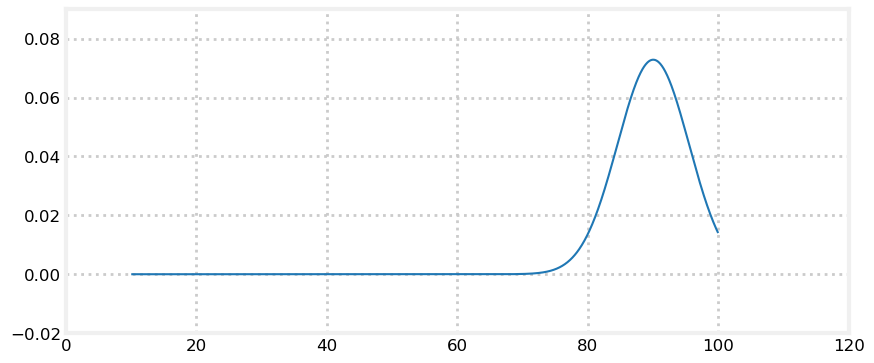

In [ ]:
xs = np.arange(10, 100, 0.05)
ys = [gaussian(x, 90, 30) for x in xs]
plt.plot(xs, ys, label='var=0.2')
plt.xlim(0, 120)
plt.ylim(-0.02, 0.09);

曲线下的面积不等于 1，因此它不是概率分布。而真实的情况是，更多的学生比正态分布预测的分数更接近范围的上限，例如，尾部会变得“胖”。此外，测试可能无法完全区分学生技能上的细微差异，因此平均值左边的分布也可能会有些杂乱无章。

传感器可以测量世界。传感器测量中的误差很少是真正的高斯分布。现在谈论这个给卡尔曼滤波器设计者所带来的困难还为时过早。卡尔曼滤波数学思想是建立在一个理想化的世界模型上的，这一点值得你铭记在心。现在，我将介绍一些代码，稍后在书中我将使用这些代码来生成分布，以模拟各种过程和传感器。此分布名为[*学生的 $t$-分布（Student's $t$-distribution）*](https://en.wikipedia.org/wiki/student%27s_-distribution)。

假设我想建立一个输出中有一些白噪声的传感器模型。为了简单起见，假设信号为常数 10，噪声的标准偏差为 2。我们可以使用函数 `numpy.random.randn()` 得到一个平均值为 0，标准偏差为 1 的随机数。我可以用以下方法模拟：

In [ ]:
from numpy.random import randn
def sense():
    return 10 + randn()*2

让我们绘制出信号的图像，看看它是什么样子的。

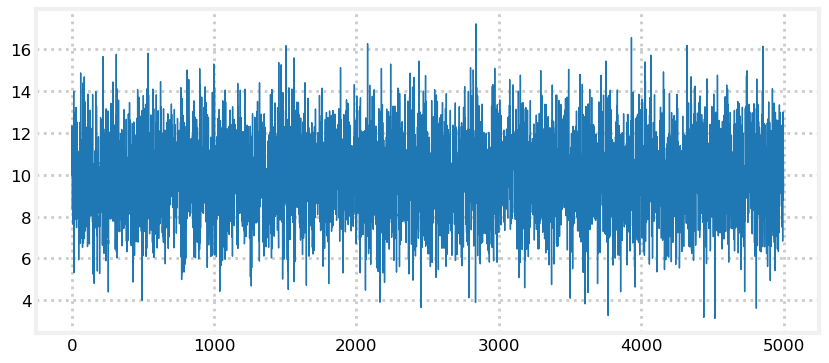

In [ ]:
zs = [sense() for i in range(5000)]
plt.plot(zs, lw=1);

看起来是我所期望的。信号的中心在 10 左右。标准偏差为 2 意味着 68% 的测量值将在 10 的 $\pm$ 2 范围之内，99% 将在 10 的 $\pm$ 6 范围之内，。

现在，让我们看看用学生的 $t$-分布生成的分布。我将不讨论数学，只给你它的源代码，然后用它绘制一个分布图。

In [ ]:
import random
import math

def rand_student_t(df, mu=0, std=1):
    """return random number distributed by Student's t 
    distribution with `df` degrees of freedom with the 
    specified mean and standard deviation.
    """
    x = random.gauss(0, std)
    y = 2.0*random.gammavariate(0.5*df, 2.0)
    return x / (math.sqrt(y / df)) + mu

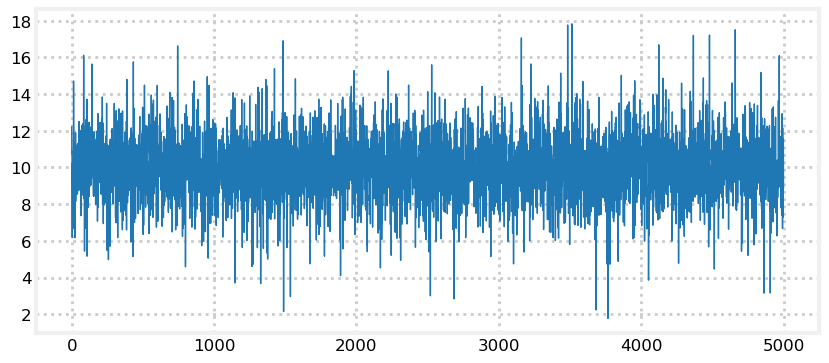

In [ ]:
def sense_t():
    return 10 + rand_student_t(7)*2

zs = [sense_t() for i in range(5000)]
plt.plot(zs, lw=1);

从图中可以看出，虽然输出与正态分布相似，但有一些离群值与平均值（7 到 13）相差超过 3 个标准差。

学生 $t$ 分布不是传感器（例如，GPS 或多普勒）运行方式的精确模型，而这本书也不是一本关于如何模拟物理系统的书。然而，它确实能产生合理的数据来测试滤波器在真实世界中的性能。在我们的模拟和测试中，我们将在书的其余部分使用类似的分布。

这并不是无关紧要的问题。卡尔曼滤波方程假设噪声是正态分布的，如果不是正态分布，则执行就不会理想。关键任务的滤波器的设计者，如航天器上的滤波器，需要掌握许多关于航天器上传感器性能的理论和经验知识。例如，我在一次美国航天局任务中看到的一个演示表明，虽然理论上说他们可以使用 3 个标准差来区分噪音和实际的有效测量，但他们必须使用 5 到 6 个标准差。这是他们通过实验确定的。

rand_student_t 的代码被包含在 `filterpy.stats` 中。你可以通过如下方式使用它：

```python
from filterpy.stats import rand_student_t
```

虽然我在这里不讨论它，但是统计学已经定义了通过概率分布与指数分布的变化来描述概率分布形状的方法。正态分布是围绕平均值对称形成的，就像钟形曲线。然而，概率分布在平均值附近可能是不对称的。这种度量称为[*偏斜（skew）*](https://en.wikipedia.org/wiki/skewness)。尾巴可以变短、变胖、变薄，或者形状不同于指数分布。这种度量方法称为[*峰度（kurtosis）*](https://en.wikipedia.org/wiki/kurtosis)。`scipy.stats` 模块包含 `describe` 函数，该函数可以计算这些统计信息。

In [ ]:
import scipy
scipy.stats.describe(zs)

DescribeResult(nobs=5000, minmax=(1.7707248080804092, 17.824961707265643), mean=10.004201301507253, variance=2.721973140216924, skewness=-0.03534037712630867, kurtosis=1.583968849611276)

让我们来检测两个正态分布，一个样本少一些，一个多一些：

In [ ]:
print(scipy.stats.describe(np.random.randn(10)))
print()
print(scipy.stats.describe(np.random.randn(300000)))

DescribeResult(nobs=10, minmax=(-1.1170056026895896, 1.0389413316321683), mean=-0.14317693801053674, variance=0.63137454114842, skewness=0.23966670696111078, kurtosis=-1.3702119526058378)

DescribeResult(nobs=300000, minmax=(-4.262303362805642, 4.603650808299195), mean=-0.00040808441709135014, variance=0.998953112076118, skewness=-0.0010979017079029859, kurtosis=-0.00030025117171517124)


小样本具有较大非零的偏斜和峰度，因为小样本的数量并没有很好地分布在平均值 0 的周围。你也可以通过将计算的平均值和方差与理论上的均值 0 和方差 1 进行比较，得出相同的结论。相比之下，大样本的平均值和方差与理论值非常接近，并且偏度和峰度都接近于零。

## 高斯分布的积（选读）

本节并不重要。在这里，我将推导两个高斯乘积的方程。

你可以通过将两个高斯方程相乘并组合项来得出结果。但是代数会很麻烦。我将用贝叶斯定理来推导它。我们可以将问题描述为：让先验概率为 $N(\bar\mu, \bar\sigma^2)$，测量值为 $z \propto N(z, \sigma_z^2)$。给定测量值 z，求后验概率 x？

把后验概率记作 $p(x \mid z)$。根据贝叶斯定理

$$p(x \mid z) = \frac{p(z \mid x)p(x)}{p(z)}$$

$p(z)$ 是一个归一化常量，因此我们可以构建一个比例关系：

$$p(x \mid z) \propto p(z|x)p(x)$$

现在我们将高斯方程代入进去，其中：

$$p(z \mid x) = \frac{1}{\sqrt{2\pi\sigma_z^2}}\exp \Big[-\frac{(z-x)^2}{2\sigma_z^2}\Big]$$

$$p(x) = \frac{1}{\sqrt{2\pi\bar\sigma^2}}\exp \Big[-\frac{(x-\bar\mu)^2}{2\bar\sigma^2}\Big]$$

我们可以去掉前导项，因为它们是常量，得到：

$$\begin{aligned}
p(x \mid z) &\propto \exp \Big[-\frac{(z-x)^2}{2\sigma_z^2}\Big]\exp \Big[-\frac{(x-\bar\mu)^2}{2\bar\sigma^2}\Big]\\
&\propto \exp \Big[-\frac{(z-x)^2}{2\sigma_z^2}-\frac{(x-\bar\mu)^2}{2\bar\sigma^2}\Big] \\
&\propto \exp \Big[-\frac{1}{2\sigma_z^2\bar\sigma^2}[\bar\sigma^2(z-x)^2-\sigma_z^2(x-\bar\mu)^2]\Big]
\end{aligned}$$

现在我们展开平方项，并根据 $x$ 合并同类项。

$$\begin{aligned}
p(x \mid z) &\propto \exp \Big[-\frac{1}{2\sigma_z^2\bar\sigma^2}[\bar\sigma^2(z^2 -2xz + x^2) + \sigma_z^2(x^2 - 2x\bar\mu+\bar\mu^2)]\Big ] \\
&\propto \exp \Big[-\frac{1}{2\sigma_z^2\bar\sigma^2}[x^2(\bar\sigma^2+\sigma_z^2)-2x(\sigma_z^2\bar\mu + \bar\sigma^2z) + (\bar\sigma^2z^2+\sigma_z^2\bar\mu^2)]\Big ]
\end{aligned}$$

最后的括号中不包含 $x$，它可以被视为常数，并被舍弃。

$$p(x \mid z) \propto \exp \Big[-\frac{1}{2}\frac{x^2(\bar\sigma^2+\sigma_z^2)-2x(\sigma_z^2\bar\mu + \bar\sigma^2z)}{\sigma_z^2\bar\sigma^2}\Big ]
$$

将分子和分母除以 $\bar\sigma^2+\sigma_z^2$ 得到

$$p(x \mid z) \propto \exp \Big[-\frac{1}{2}\frac{x^2-2x(\frac{\sigma_z^2\bar\mu + \bar\sigma^2z}{\bar\sigma^2+\sigma_z^2})}{\frac{\sigma_z^2\bar\sigma^2}{\bar\sigma^2+\sigma_z^2}}\Big ]
$$

比例关系允许我们随意增加或删除常量，因此我们可以将其写为：

$$p(x \mid z) \propto \exp \Big[-\frac{1}{2}\frac{(x-\frac{\sigma_z^2\bar\mu + \bar\sigma^2z}{\bar\sigma^2+\sigma_z^2})^2}{\frac{\sigma_z^2\bar\sigma^2}{\bar\sigma^2+\sigma_z^2}}\Big ]
$$

得到一个高斯方程

$$N(\mu,\, \sigma^2) \propto \exp\Big [-\frac{1}{2}\frac{(x - \mu)^2}{\sigma^2}\Big ]$$

$p(x \mid z)$ 的均值为

$$\mu_\mathtt{posterior} = \frac{\sigma_z^2\bar\mu + \bar\sigma^2z}{\bar\sigma^2+\sigma_z^2}$$

它的方差是

$$
\sigma_\mathtt{posterior} = \frac{\sigma_z^2\bar\sigma^2}{\bar\sigma^2+\sigma_z^2}
$$

我在推导过程中去掉了常数，所以结果不是一个正态分布，而是与其成比例。贝叶斯定理使用除以 $p(z)$ 使其归一化，确保结果是正态的。我们在滤波器的更新步骤中也进行了归一化，确保滤波器估计值是高斯的。

$$\mathcal N_1 = \| \mathcal N_2\cdot \mathcal N_3\|$$

## 高斯分布的和（选读）

同样，本节也不是阅读的重点。本节我将推导两个高斯分布的和。

两个高斯分布的和由如下组成：

$$\begin{gathered}\mu = \mu_1 + \mu_2 \\
\sigma^2 = \sigma^2_1 + \sigma^2_2
\end{gathered}$$

有几种方法可以证明。我将使用卷积来证明，因为我们在上一章中使用了卷积来表示概率的柱状图。

为了求两个高斯随机变量之和的密度函数，我们需要求出了每个变量的密度函数之和。它们是非线性的连续函数，所以我们需要用一个积分来计算和。假设随机变量（例如先验和测量） $p$ 和 $z$ 是独立的，我们可以用

$p(x) = \int\limits_{-\infty}^\infty f_p(x-z)f_z(z)\, dx$

这是卷积方程。现在我们做数学证明：

$p(x) = \int\limits_{-\infty}^\infty f_2(x-x_1)f_1(x_1)\, dx$

$=  \int\limits_{-\infty}^\infty 
\frac{1}{\sqrt{2\pi}\sigma_z}\exp\left[-\frac{(x - z - \mu_z)^2}{2\sigma^2_z}\right]
\frac{1}{\sqrt{2\pi}\sigma_p}\exp\left[-\frac{(x - \mu_p)^2}{2\sigma^2_p}\right] \, dx$

$=  \int\limits_{-\infty}^\infty
\frac{1}{\sqrt{2\pi}\sqrt{\sigma_p^2 + \sigma_z^2}} \exp\left[ -\frac{(x - (\mu_p + \mu_z)))^2}{2(\sigma_z^2+\sigma_p^2)}\right]
\frac{1}{\sqrt{2\pi}\frac{\sigma_p\sigma_z}{\sqrt{\sigma_p^2 + \sigma_z^2}}} \exp\left[ -\frac{(x - \frac{\sigma_p^2(x-\mu_z) + \sigma_z^2\mu_p}{}))^2}{2\left(\frac{\sigma_p\sigma_x}{\sqrt{\sigma_z^2+\sigma_p^2}}\right)^2}\right] \, dx$

$= \frac{1}{\sqrt{2\pi}\sqrt{\sigma_p^2 + \sigma_z^2}} \exp\left[ -\frac{(x - (\mu_p + \mu_z)))^2}{2(\sigma_z^2+\sigma_p^2)}\right] \int\limits_{-\infty}^\infty
\frac{1}{\sqrt{2\pi}\frac{\sigma_p\sigma_z}{\sqrt{\sigma_p^2 + \sigma_z^2}}} \exp\left[ -\frac{(x - \frac{\sigma_p^2(x-\mu_z) + \sigma_z^2\mu_p}{}))^2}{2\left(\frac{\sigma_p\sigma_x}{\sqrt{\sigma_z^2+\sigma_p^2}}\right)^2}\right] \, dx$


积分内部的表达式是正态分布。正态分布的和是 1，因此积分是 1。于是我们可以得出：

$$p(x) = \frac{1}{\sqrt{2\pi}\sqrt{\sigma_p^2 + \sigma_z^2}} \exp\left[ -\frac{(x - (\mu_p + \mu_z)))^2}{2(\sigma_z^2+\sigma_p^2)}\right]$$

这是正态分布的形式，其中

$$\begin{gathered}\mu_x = \mu_p + \mu_z \\
\sigma_x^2 = \sigma_z^2+\sigma_p^2\end{gathered}$$

## 总结和重点

本章对统计的总体知识介绍并不多。我只在书中介绍了使用高斯分布所需的概念，不再赘述。如果你想阅读卡尔曼滤波器的文献，我所介绍的内容不会对你有太大的帮助。如果这对你来说是个新课题，我建议你读一本统计学教科书。我一直喜欢 Schaum 系列用于自学，Alan Downey 的*思考统计资料*也非常好，可以在网上免费获得。

在我们继续之前，你**必须**理解以下几点：

* 正态分布表示一个连续的概率分布

* 它可以由两个参数来描述：平均值（$\mu$）和方差（$\sigma^2$）

* $\mu$ 是所有可能值的平均值

* 方差 $\sigma^2$ 表示我们的测量值与平均值之间的差异。

* 标准差（$\sigma$）是方差的平方根（$\sigma^2$）

* 自然界中有许多事物可以近似于正态分布，但在数学上并不完美。

* 在滤波问题中，计算 $p(x\mid z)$ 几乎是不可能的，但是计算 $p(z\mid x)$ 是很简单的。贝叶斯定理让我们可以从后者计算出前者。

接下来的几章将使用利用贝叶斯定理和高斯分布来帮助实现滤波。如前一节所述，有时高斯分布对物理世界的描述并不太好。本书后面的部分将专门介绍滤波器，即使在噪声或系统行为非常高斯的情况下，滤波器也能工作。

## 参考文献

[1] https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/Supporting_Notebooks/Computing_and_plotting_PDFs.ipynb

[2] http://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

[3] http://docs.scipy.org/doc/scipy/reference/tutorial/stats.html

[4] Huber, Peter J. *Robust Statistical Procedures*, Second Edition. Society for Industrial and Applied Mathematics, 1996.

[5] Downey, Alan. *Think Stats*, Second Edition. O'Reilly Media.

https://github.com/AllenDowney/ThinkStats2

http://greenteapress.com/thinkstats/

## 一些有用的维基百科链接

https://en.wikipedia.org/wiki/Probability_distribution

https://en.wikipedia.org/wiki/Random_variable

https://en.wikipedia.org/wiki/Sample_space

https://en.wikipedia.org/wiki/Central_tendency

https://en.wikipedia.org/wiki/Expected_value

https://en.wikipedia.org/wiki/Standard_deviation

https://en.wikipedia.org/wiki/Variance

https://en.wikipedia.org/wiki/Probability_density_function

https://en.wikipedia.org/wiki/Central_limit_theorem

https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule

https://en.wikipedia.org/wiki/Cumulative_distribution_function

https://en.wikipedia.org/wiki/Skewness

https://en.wikipedia.org/wiki/Kurtosis